# Pythonic process Based Modeling 
Implements process-based modeling into python.

## Implementation 
- **on surface**: process-based modeling (entities & processes)
- **low level**: just **variables** & **constants** 

PBM implementation: [PyBM/src/pybm/model.py](/home/urhp/Documents/PyBM/src/pybm/model.py)

Estimation using Scipy: [PyBM/src/pybm/estimate/int_scipy.py](/home/urhp/Documents/PyBM/src/pybm/estimate/int_scipy.py)

Estimation using Torch: [PyBM/src/pybm/estimate/int_torch.py](/home/urhp/Documents/PyBM/src/pybm/estimate/int_torch.py)

## Syntax
No more type annotations.

In [1]:
from pybm.model import VarTemp, ConstTemp, EntityTemp, Model, Var

# new particle template 
particle_template = EntityTemp(
    VarTemp("x"),
    VarTemp("y"),
    ConstTemp("k", initial_value=0.5)
)
# create one instance of the template
neon_particle = particle_template(name="neon_particle")

# create another and add a new variable to it
higgs_boson = particle_template(name="higgs_boson")
# add a new variable to the higgs_boson instance
higgs_boson.add(Var("spin"))

# create a new model
particle_model = Model(neon_particle, higgs_boson)

print(str(particle_model))

Model(Entities: ['neon_particle', 'higgs_boson'],
 Vars: ['neon_particle.x', 'neon_particle.y', 'higgs_boson.x', 'higgs_boson.y', 'higgs_boson.spin'],
 Consts: ['neon_particle.k', 'higgs_boson.k'])


Less is more. No need for templates.

In [2]:
from pybm.model import Var, Const, Entity

# Entities, variables and constants can be created directly.
v1 = Var("x")
v2 = Var("y")
c1 = Const("mass", initial_value=0.5)
particle = Entity(v1, v2, c1, name="particle")

small_particle_model = Model(particle)
print(str(small_particle_model))

Model(Entities: ['particle'],
 Vars: ['particle.x', 'particle.y'],
 Consts: ['particle.mass'])


## Example 
This small predator-prey model will work as a example. We have two wariables:
- $n_{\mathrm{prey}}(t)$: prey population size,
- $n_{\mathrm{predator}}(t)$: predator population size.

Growth of both populations is effected by *exo* variable **temperature**, which folows this equation:
$$
T(t) = 1 + A \sin\left(\frac{2\pi t}{P}\right),
$$
where $A=2$.

### Processes

The prey population grows at a temperature-dependent rate:

$$
\mathrm{Growth}_{\mathrm{prey}}
=
T(t)\,r_{\mathrm{prey}}\,n_{\mathrm{prey}}(t).
$$

Predators have a temperature-dependent background mortality:

$$
\mathrm{Background}_{\mathrm{predator}}
=
T(t)\,r_{\mathrm{predator}}\,n_{\mathrm{predator}}(t),
$$

Where $r_{\mathrm{predator}} < 0$.

Predation removes prey:

$$
\mathrm{Predation}
=
a\,n_{\mathrm{prey}}(t)\,n_{\mathrm{predator}}(t).
$$

A fraction $e$ of consumed prey is converted into predator population growth:

$$
\mathrm{Predator\ gain}
=
e\,a\,n_{\mathrm{prey}}(t)\,n_{\mathrm{predator}}(t).
$$

## Ordinary differential equations

The prey ODE is the sum of prey growth and the negative predation contribution:

$$
\frac{d n_{\mathrm{prey}}}{dt}
=
T(t)\,r_{\mathrm{prey}}\,n_{\mathrm{prey}}(t)
-
a\,n_{\mathrm{prey}}(t)\,n_{\mathrm{predator}}(t).
$$

The predator ODE is the sum of background mortality and gain from predation:

$$
\frac{d n_{\mathrm{predator}}}{dt}
=
T(t)\,r_{\mathrm{predator}}\,n_{\mathrm{predator}}(t)
+
e\,a\,n_{\mathrm{prey}}(t)\,n_{\mathrm{predator}}(t).
$$

## Constants

The synthetic-data example uses the following constants:

- $A = 0.2$: amplitude of temperature variation.
- $P = 10.0$: temperature period, in days.
- $r_{\mathrm{prey}} = 0.5$: baseline prey growth rate.
- $r_{\mathrm{predator}} = -0.2$: baseline predator growth or mortality rate.
- $a = 0.02$: predation rate.
- $e = 0.1$: conversion efficiency from consumed prey to predator growth.

The initial conditions are:

$$
n_{\mathrm{prey}}(0) = 40,
$$

$$
n_{\mathrm{predator}}(0) = 8.
$$

Implementation of the model is in [/PyBM/src/pybm/examples/predator_prey.py](/home/urhp/Documents/PyBM/src/pybm/examples/predator_prey.py)

In [3]:
from pybm.examples.predator_prey import  generate_synthetic_data

# Generate model and data from /home/urhp/Documents/PyBM/src/pybm/examples/predator_prey.py
model, components, times = generate_synthetic_data()
print(str(model))

# print initial values of the variables
print("Initial values of the variables:")
for var_name, var in model.vars.items():
    print(f"{var_name}: {var.initial}")  

# set initial values of the constants to good guesses
model.consts["growth_rate_prey"].initial_value = 0.5
model.consts["growth_rate_predator"].initial_value = -0.1
model.consts["predation_rate"].initial_value = 0.05
model.consts["conversion_efficiency"].initial_value = 0.05



# print initial values of the constants
print("\nInitial values of the constants:")
for const_name, const in model.consts.items():
    print(f"{const_name}: {const.initial_value}")


Model(Entities: [],
 Vars: ['n_prey', 'n_predator', 'temperature'],
 Consts: ['growth_rate_prey', 'growth_rate_predator', 'predation_rate', 'conversion_efficiency'])
Initial values of the variables:
n_prey: 40.000492061342996
n_predator: 8.016754323781468
temperature: None

Initial values of the constants:
growth_rate_prey: 0.5
growth_rate_predator: -0.1
predation_rate: 0.05
conversion_efficiency: 0.05


In [4]:
from cma import fmin2, CMAEvolutionStrategy
from pybm.estimate.int_scipy import get_data_matrix, get_initial_const_ctx, simulate
import numpy as np

if False:
    vars = model.get_endo_variables()
    # get the data, that we want to fit the model to
    data = get_data_matrix(*vars, t_eval=times)
    # initial context:
    initial_ctx = get_initial_const_ctx(model)

    def residuals(const_ctx):
        # get predictions
        sol = simulate(*vars, t_eval=times, const_ctx=const_ctx)
        pred = sol.y # of shape (n_vars, n_time_points)
        try:
            return (pred - data ).ravel()
        except Exception as e:
            print("Error in residuals calculation")
            print(f"pred shape: {pred.shape}, data shape: {data.shape}")
            print(sol)

    def fitness(const_ctx):
        res = residuals(const_ctx)
        return np.sum(res**2)

    # xopt, es = fmin2(fitness, initial_ctx, sigma0=0.5, options={'maxiter': 10, 'verb_disp': 1})
    es = CMAEvolutionStrategy(initial_ctx, 0.5)
    es.optimize(fitness, iterations=10)

Estimate 

In [5]:
from pybm.estimate.int_scipy import estimate as estimate_scipy
const_values, loss = estimate_scipy(model=model, t_eval=times, verbose=2)  # verbose=2 for more detailed output

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         1.1065e+07                                    1.67e+08    
       1              4         9.3490e+06      1.72e+06       3.22e-02       1.29e+09    
       2              5         2.5463e+06      6.80e+06       3.22e-02       7.68e+07    
       3              6         1.9427e+05      2.35e+06       6.43e-02       1.29e+08    
       4              8         9.5743e+04      9.85e+04       3.22e-02       1.12e+08    
       5              9         3.9568e+04      5.62e+04       3.22e-02       3.39e+08    
       6             10         8.3725e+03      3.12e+04       1.78e-02       2.28e+07    
       7             12         5.7520e+03      2.62e+03       2.50e-03       3.15e+06    
       8             14         5.5628e+03      1.89e+02       1.25e-03       3.72e+06    
       9             15         5.4521e+03      1.11e+02       2.50e-03       1.20e+07    

In [6]:
for const_name, const in model.consts.items():
    # set new estimated values to the model constants 
    const.initial_value = const_values[const.index_in_ctx]

# dictionary of names and true values of the constants for comparison
true_const_values = {
    "growth_rate_prey": 0.5,
    "growth_rate_predator": -0.1,
    "predation_rate": 0.02,
    "conversion_efficiency": 0.1
}

# print the estimated values of the constants
print("\nEstimated values of the constants:")
for const_name, const in model.consts.items():
    print(f"{const_name}: {round(const.initial_value, 2)}, true value: {true_const_values[const_name]}")


Estimated values of the constants:
growth_rate_prey: 0.51, true value: 0.5
growth_rate_predator: -0.19, true value: -0.1
predation_rate: 0.02, true value: 0.02
conversion_efficiency: 0.09, true value: 0.1


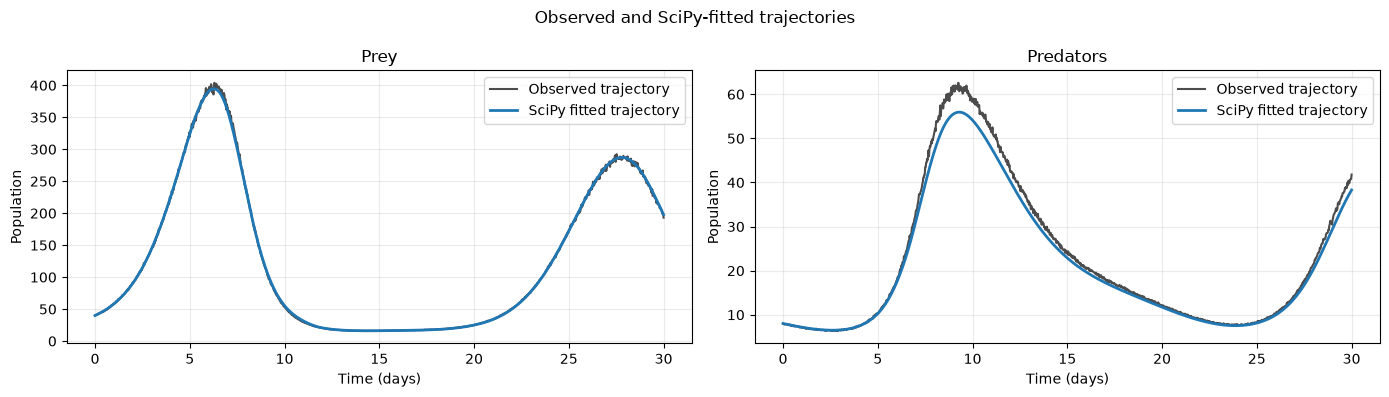

In [7]:
import matplotlib.pyplot as plt
from pybm.estimate.int_scipy import simulate as simulate_scipy

# Simulacija z ocenjenimi SciPy parametri
fitted_solution = simulate_scipy(
    *model.get_endo_variables(),
    t_eval=times,
    const_ctx=const_values,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=True)

series = [
    ("n_prey", "Prey"),
    ("n_predator", "Predators"),
]

for index, (name, title) in enumerate(series):
    ax = axes[index]
    observed = components[name].data.x

    ax.plot(
        times, observed,
        label="Observed trajectory",
        color="black",
        alpha=0.7,
    )
    ax.plot(
        times, fitted_solution.y[index],
        label="SciPy fitted trajectory",
        color="tab:blue",
        linewidth=2,
    )

    ax.set_title(title)
    ax.set_xlabel("Time (days)")
    ax.set_ylabel("Population")
    ax.grid(alpha=0.25)
    ax.legend()

fig.suptitle("Observed and SciPy-fitted trajectories")
fig.tight_layout()
plt.show()

## Torch optimisation (autograd)

In [8]:
from pybm.estimate.int_torch import estimate as estimate_torch
import torch
# set initial values of the constants to good guesses
model.consts["growth_rate_prey"].initial_value = 0.5
model.consts["growth_rate_predator"].initial_value = -0.1
model.consts["predation_rate"].initial_value = 0.05
model.consts["conversion_efficiency"].initial_value = 0.05
# torch - change numpy arrays to torch tensors
for var_name, var in model.vars.items():
    if var.data is not None:
        var.data.to_torch()
# change times to a torch tensor
t_eval = torch.tensor(times, requires_grad=True)
# reshape into (1, n_times)
#t_eval = torch.reshape(t_eval, (1, -1))

In [9]:
#const_values_torch, loss_torch = estimate_torch(model=model, t_eval=t_eval,
#                                                line_search_fn="strong_wolfe", lr=0.1, max_iter=50,
#                                                tolerance_grad=1e-03, tolerance_change=1e-05)  # verbose=2 for more detailed output
const_values_torch, loss_torch = estimate_torch(model=model, t_eval=t_eval, 
                                                opt="adam", lr=0.01, max_iter=200)  


print("Loss: ", loss_torch)

Loss:  0.008541863761558797


In [10]:
# update model constants with estimated values
for const_name, const in model.consts.items():
    const.initial_value = const_values_torch[const.index_in_ctx].item()

print("\nEstimated values of the constants:")
for const_name, const in model.consts.items():
    print(f"{const_name}: {round(const.initial_value, 2)}, true value: {true_const_values[const_name]}")


Estimated values of the constants:
growth_rate_prey: 0.6, true value: 0.5
growth_rate_predator: -0.16, true value: -0.1
predation_rate: 0.03, true value: 0.02
conversion_efficiency: 0.05, true value: 0.1


/home/urhp/Documents/PyBM/src/pybm/estimate/int_scipy.py:101: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:838.)
  derivatives[var.index_in_ctx] = var.ode(t, new_ctx)


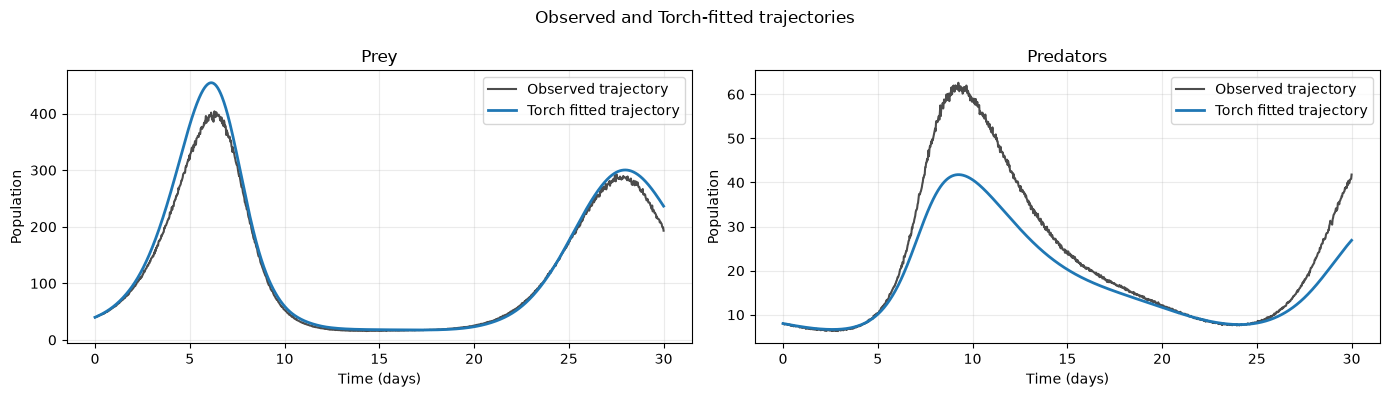

In [11]:
import matplotlib.pyplot as plt
from pybm.estimate.int_scipy import simulate as simulate_scipy

# Simulacija z ocenjenimi SciPy parametri
fitted_solution = simulate_scipy(
    *model.get_endo_variables(),
    t_eval=times,
    const_ctx=const_values_torch,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=True)

series = [
    ("n_prey", "Prey"),
    ("n_predator", "Predators"),
]

for index, (name, title) in enumerate(series):
    ax = axes[index]
    observed = components[name].data.x

    ax.plot(
        times, observed,
        label="Observed trajectory",
        color="black",
        alpha=0.7,
    )
    ax.plot(
        times, fitted_solution.y[index],
        label="Torch fitted trajectory",
        color="tab:blue",
        linewidth=2,
    )

    ax.set_title(title)
    ax.set_xlabel("Time (days)")
    ax.set_ylabel("Population")
    ax.grid(alpha=0.25)
    ax.legend()

fig.suptitle("Observed and Torch-fitted trajectories")
fig.tight_layout()
plt.show()

## If-else inside ODE
PyBM allows arbitrary python code inside ODEs. 

Here we study a simple model with one variable $x' = \begin{cases} 1 & t \leq 1 \\ -1 & t  >  1\end{cases}$ and $x(0) = 0$.

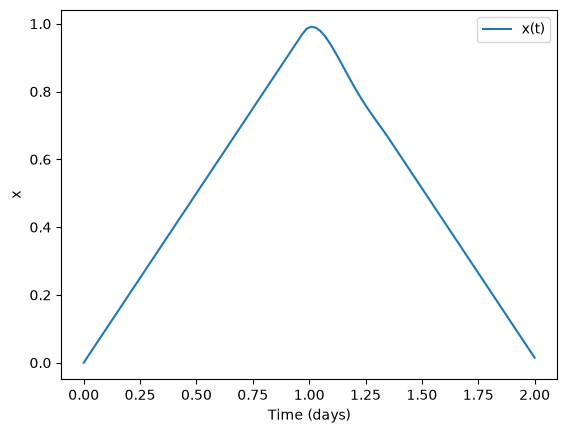

In [12]:
import numpy as np
from pybm.model import Model, Var, Const
from pybm.estimate.int_scipy import simulate as simulate_scipy
from pybm.estimate.int_scipy import estimate as estimate_scipy
x = Var("x", initial=0, type="endo")

model = Model(x)

t = np.linspace(0, 2, 100)

def rhs(t, ctx):
    if t <= 1:
        return 1
    else:
        return -1

x.ode = rhs 

# simulate 
sol = simulate_scipy(x, t_eval=t, const_ctx=[])

plt.plot(t, sol.y[0], label="x(t)")
plt.xlabel("Time (days)")
plt.ylabel("x")
plt.legend()
plt.show()


Estimation with if statements in ode:

In [27]:
import numpy as np
from pybm.model import Model, Var, Const
from pybm.estimate.int_scipy import set_consts
from pybm.estimate.int_scipy import simulate as simulate_scipy
from pybm.estimate.int_scipy import estimate as estimate_scipy
x = Var("x", initial=0, type="endo")
c1 = Const("c1", initial_value=0)
c2 = Const("c2", initial_value=0)

model = Model(x, c1, c2)



def rhs(t, ctx):
    if t <= 1:
        return c1(ctx)
    else:
        return c2(ctx)
# add equation
x.ode = rhs 
# add data for x - use previously simulated data
x.set_data(t,sol.y[0] )


# estimate constants with SciPy
const_ctx, loss = estimate_scipy(model=model, t_eval=t, verbose=2)  # verbose=2 for more detailed output

# set the estimated values of the constants in the model
set_consts(model, const_ctx)

print("\nEstimated values of the constants:")
print("c1:", c1.initial_value)
print("c2:", c2.initial_value)

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         1.6928e+01                                    4.17e+01    
       1              2         6.8467e-01      1.62e+01       1.00e+00       3.07e+00    
       2              3         3.0553e-01      3.79e-01       4.06e-01       7.13e+00    
       3              4         2.2426e-05      3.06e-01       9.27e-02       6.55e-02    
       4              5         3.0822e-14      2.24e-05       6.46e-04       2.42e-06    
       5              6         1.1471e-30      3.08e-14       2.32e-08       4.20e-15    
`gtol` termination condition is satisfied.
Function evaluations 6, initial cost 1.6928e+01, final cost 1.1471e-30, first-order optimality 4.20e-15.

Estimated values of the constants:
c1: 1.0
c2: -0.9999999999999999


## Constants in condition

Let us first study a clasical optimisation problem without any ODE integration. We have a model 
$$
f_c(x) = \begin{cases}
a & x \leq c \\
b & x > c
\end{cases}
$$
and ground truth f_1(x). We only have access to a sample of values $(x_i, f_1(x_i))_{i = 1}^n$ and we want to optimize $c$ based on this values.
We want to optimize mean squared error on a sample:
$$
\mathcal L (c) = \sum_{i = 1}^n  (f_1(x_i) - f_c(x_i))^2,
$$
which **has zero gradient** (where it exists). 
If our optimizing algorithm is gradient-based (`least_squares` from `scipy`,...), than optimisation wont work. In order to use 
gradient-based methods, one can relaxe the problem with introducing relaxed model such as
$$
f_c(x) = \frac{tanh(\frac{c - a}{\epsilon}) + 1}{2}(b-a) + a,
$$
which is suitable for gradient-based optimisation.

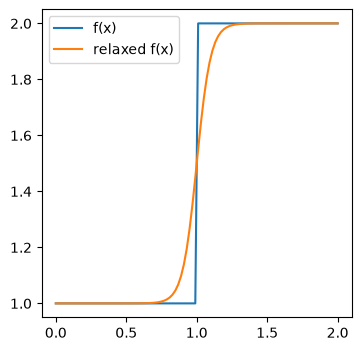

In [28]:
import matplotlib.pyplot as plt

a = 1
b = 2
f = lambda x : a if x <= 1 else b
relaxed_f = lambda x : 0.5 * (1 + np.tanh((x-a)/0.1))*(b-a) + a
ts = np.linspace(0, 2, 100)
fs = [f(t) for t in ts]
rfs = [relaxed_f(t) for t in ts]

plt.figure(figsize=(4, 4))
plt.plot(ts, fs, label="f(x)")
plt.plot(ts, rfs, label="relaxed f(x)")
plt.legend()
plt.show()


PyBM implements **relaxed if-esle** statements with `pybm.conditional.RelaxedIfElse`. In order to use gradient-based methods for estimation, this conditionals (or other relaxed versions) should be used instead of vanilla if-else.

Not all if-else statements can be converted into relaxed versions. Suitable ones can be written in a form 
```
if value_1 <= 0:
    expr_1 
elif value_2 <= 0:
    expr_2
    .
    .
    .
elif value_n <= 0:
    expr_n
else:
    expr_n+1
```
and are rewritten in relaxed form as 
```
RelaxedIfElse().If(value_1, expr_1).Elif(value_2,expr_2)....Elif(value_n, expr_n).Else(expr_n+1)
```

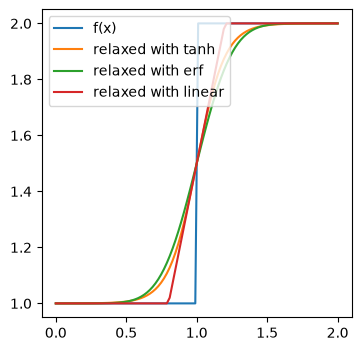

In [29]:
from pybm.conditional import RelaxedIfElse

eps = 0.2
def rf_tanh(x):
    return RelaxedIfElse(eps=eps).If(x-1,a).Else(b)

def rf_erf(x):
    return RelaxedIfElse(eps=eps, method="erf").If(x-1,a).Else(b)

def rf_linear(x):
    return RelaxedIfElse(eps=eps, method="linear").If(x-1,a).Else(b)

rfs_tanh = [rf_tanh(t) for t in ts]
rfs_erf = [rf_erf(t) for t in ts]
rfs_linear = [rf_linear(t) for t in ts]

plt.figure(figsize=(4, 4))
plt.plot(ts, fs, label="f(x)")
plt.plot(ts, rfs_tanh, label="relaxed with tanh")
plt.plot(ts, rfs_erf, label="relaxed with erf")
plt.plot(ts, rfs_linear, label="relaxed with linear")
plt.legend(loc="upper left")
plt.show()

Now we will again try to model the data $(t_i,x_i)_{i}$, sampled with noise from equation 
$$
x' = \begin{cases} 1 & t \leq 1 \\ -1 & t  >  1 \end{cases}
$$
but this time, we will use a model with constant inside if condition: 
$x' = \begin{cases} 1 & t \leq c \\ -1 & t  >  c \end{cases}$ and try to estimate $c$. 

In [42]:
import numpy as np
from pybm.model import Model, Var, Const
from pybm.estimate.int_scipy import set_consts
from pybm.estimate.int_scipy import simulate as simulate_scipy
from pybm.estimate.int_scipy import estimate as estimate_scipy

x = Var("x", initial=0, type="endo")
c = Const("c", initial_value=0.5)
model = Model(x, c)

############################################################
## prepare artifitial data                                 #
t = np.linspace(0, 2, 100)                                 #    
                                                           #
def rhs(t, ctx):                                           # 
    if t <= 1:                                             #
        return 1                                           #
    else:                                                  #
        return -1                                          #
                                                           #
x.ode = rhs                                                #
                                                           #       
# simulate                                                 # 
sol = simulate_scipy(x, t_eval=t, const_ctx=[])            #
# save and add noise to the data for x                     #            
noise = np.random.normal(0, 0.01, size=sol.y[0].shape)      #
true_x = sol.y[0] + noise                                  #
############################################################



# Use relaxed if-else in the ODE definition
def rhs(t, ctx):
    return RelaxedIfElse(eps=0.01).If(t-c(ctx), 1).Else(-1)
    
# add equation
x.ode = rhs 
# add data for x - use previously simulated data
x.set_data(t,true_x)



# estimate constants with SciPy
const_ctx, loss = estimate_scipy(model=model, t_eval=t, verbose=2)  # verbose=2 for more detailed output

print(const_ctx, ", ", loss)

# set the estimated values of the constants in the model
set_consts(model, const_ctx)

print("\nEstimated values of the constants:")
print("c:", c.initial_value)
const_ctx

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         3.1384e+01                                    1.11e+02    
       1              2         6.0999e-03      3.14e+01       5.00e-01       3.81e+01    
       2              4         5.3348e-03      7.65e-04       2.20e-05       3.11e+01    
       3              8         5.3135e-03      2.13e-05       6.87e-07       3.08e+01    
       4             10         5.3030e-03      1.06e-05       3.44e-07       3.07e+01    
       5             11         5.2820e-03      2.10e-05       6.87e-07       3.04e+01    
       6             14         5.2794e-03      2.61e-06       8.59e-08       3.04e+01    
       7             16         5.2781e-03      1.30e-06       4.30e-08       1.15e+06    
       8             17         5.2780e-03      4.74e-08       1.56e-09       1.15e+06    
`xtol` termination condition is satisfied.
Function evaluations 17, initial cost 3.1384e+0

array([1.00002385])

In [45]:
import numpy as np
from pybm.model import Model, Var, Const
from pybm.estimate.int_scipy import set_consts
from pybm.estimate.int_scipy import simulate as simulate_scipy
from pybm.estimate.int_scipy import estimate as estimate_scipy

x = Var("x", initial=0, type="endo")
# add data for x - use previously simulated data
x.set_data(t,true_x)

# new model
c_1 = Const("c_1", initial_value=0.5)
c_2 = Const("c_2", initial_value=1.5)
t_0 = Const("t_0", initial_value=0.5)
model = Model(x, t_0, c_1, c_2)




# Use relaxed if-else in the ODE definition
def rhs(t, ctx):
    return RelaxedIfElse(eps=0.01).If(t-t_0(ctx), c_1(ctx)).Else(c_2(ctx))
    
# add equation
x.ode = rhs 




# estimate constants with SciPy
const_ctx, loss = estimate_scipy(model=model, t_eval=t, verbose=2)  # verbose=2 for more detailed output

print(const_ctx, ", ", loss)

# set the estimated values of the constants in the model
set_consts(model, const_ctx)

print("\nEstimated values of the constants:")
print("c_1:", c_1.initial_value)
print("c_2:", c_2.initial_value)
print("t_0:", t_0.initial_value)
const_ctx

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         5.4913e+01                                    8.96e+01    
       1              2         3.9357e+01      1.56e+01       1.66e+00       1.41e+02    
       2              3         2.1632e-02      3.93e+01       1.32e+00       8.05e+01    
       3              4         6.2247e-03      1.54e-02       1.78e-02       5.20e+00    
       4              6         5.9896e-03      2.35e-04       1.25e-04       9.41e-01    
       5              8         5.9789e-03      1.07e-05       3.13e-05       3.26e-01    
       6             10         5.9769e-03      2.03e-06       7.83e-06       1.87e-01    
       7             11         5.9754e-03      1.50e-06       7.83e-06       1.86e-01    
       8             12         5.9724e-03      2.96e-06       1.57e-05       1.86e-01    
       9             13         5.9681e-03      4.26e-06       3.13e-05       3.52e-01    

array([ 0.99425767,  1.00051801, -1.00077458])

This way, fitting works even for constants, used in conditions. Convergence strongly depends on the **hyperparameter `eps`** inside `RelaxedIfElse(eps=...)`. 
Large values of `eps` will result in bad approximations of a model. Small values will resolut in slow or unsuccessful convergence.

### Example - more constants
Lets now study the previous dataset with a more complicated model 
$x' = \begin{cases} c_1 & t \leq t_0 \\ c_2 & t  >  t_0 \end{cases}$.

## Choose between different equations

In [17]:
from pybm.model import Choose

# create a fresh model and add a simple entity 
model = Model()
particle = Entity(Var("x"), name="particle", active_model=model)

# add equation for the particle 
# right side of the equation: 
def rs_exp(t):
    return particle["x"]

def rs_const(t):
    return 0 

# add a choice for the right side of the equation
particle.get("x").ode = Choose(rs_exp, rs_const)

#################################
# induce models
#################################

induced_models = model.induce()
for i, model in enumerate(induced_models):
    print(f"Induced model {i}:")
    print(str(model))
    print("equation:" , model.vars["particle.x"].ode)

Induced model 0:
Model(Entities: ['particle'],
 Vars: ['particle.x'],
 Consts: [])
equation: <function rs_exp at 0x79233b5d4f60>
Induced model 1:
Model(Entities: ['particle'],
 Vars: ['particle.x'],
 Consts: [])
equation: <function rs_const at 0x79233b5d5010>


# New features
- gradient-based estimation (in progress, add multishooting and/or cmaes for initial value of a c-trajectory)
- constants inside if-statements - solved with `RelaxedIfElse`

# TODO 

## Urgent  
- CMAES , Jax
- Constants inside if statements (` if f(c) ...`) -- Done ✅ *solved with `RelaxedIfElse`*
- Implement `Process` and `ProcessTemplate`
- Finish induction of models 
- Automatically conver ProBMoT to PyBM code (as in 
[/PyBM/bled/bled.py](/home/urhp/Documents/PyBM/bled/bled.py))

## Other
- JAX (better implementations of optimisation algos)
- test different algoritms
- better estimation:
  - Short hyperparam search 
  - Integrate on smaller intervals, use multi-shooting, continue just if trajectory is good, use priority queue on different models 
  - Stop integration, if the error of integration is too big (no additional knowledge!)
  - if the data is dense, use **numerical derivatives** for speedup 
- Improved syntax  
- AutoML on the data??
